In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import os
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil di-import!")

Library berhasil di-import!


In [4]:
# Mundur satu folder ('../') ke 'dataset_raw'
file_path = '../dataset_raw/credit_scoring_raw.csv'
df = pd.read_csv(file_path)

print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


Informasi Tipe Data dan Missing Values:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   checking_status         1000 non-null   str  
 1   duration                1000 non-null   int64
 2   credit_history          1000 non-null   str  
 3   purpose                 1000 non-null   str  
 4   credit_amount           1000 non-null   int64
 5   savings_status          1000 non-null   str  
 6   employment              1000 non-null   str  
 7   installment_commitment  1000 non-null   int64
 8   personal_status         1000 non-null   str  
 9   other_parties           1000 non-null   str  
 10  residence_since         1000 non-null   int64
 11  property_magnitude      1000 non-null   str  
 12  age                     1000 non-null   int64
 13  other_payment_plans     1000 non-null   str  
 14  housing                 1000 non-null   str 

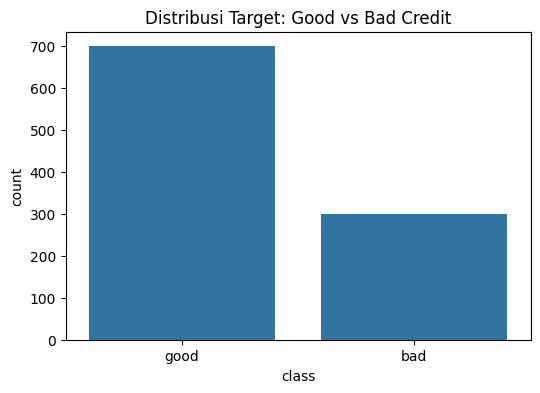

In [5]:
print("Informasi Tipe Data dan Missing Values:")
print(df.info())

print("\nDistribusi Kelas Target (Credit Risk):")
target_col = 'class'
print(df[target_col].value_counts())

# Visualisasi sederhana
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col)
plt.title('Distribusi Target: Good vs Bad Credit')
plt.show()

In [6]:
# 1. Menangani Data Kosong (Missing Values)
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())
    
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# 2. Encoding Data Kategorikal (Label Encoding)
le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = le.fit_transform(df[col])

print("\nDataset setelah preprocessing:")
df.head()


Dataset setelah preprocessing:


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,1,6,1,6,1169,4,3,4,3,2,...,3,67,1,1,2,1,1,1,1,1
1,0,48,3,6,5951,2,0,2,0,2,...,3,22,1,1,1,1,1,0,1,0
2,3,12,1,2,2096,2,1,2,3,2,...,3,49,1,1,1,3,2,0,1,1
3,1,42,3,3,7882,2,1,2,3,1,...,1,45,1,0,1,1,2,0,1,1
4,1,24,2,4,4870,2,0,3,3,2,...,2,53,1,0,2,1,2,0,1,0
